In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [4]:
import os
file_path = "Unemployment_Rate_upto_11_2020.csv"
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"File '{file_path}' loaded successfully.")
else:
    print(f"Error: File '{file_path}' not found. Please ensure the file is uploaded or the path is correct.")
    print("You might need to upload the file to your Colab session or provide the full path if it's in Google Drive.")

File 'Unemployment_Rate_upto_11_2020.csv' loaded successfully.


In [5]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [7]:
df.columns = df.columns.str.strip()

In [8]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_54629/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [11]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


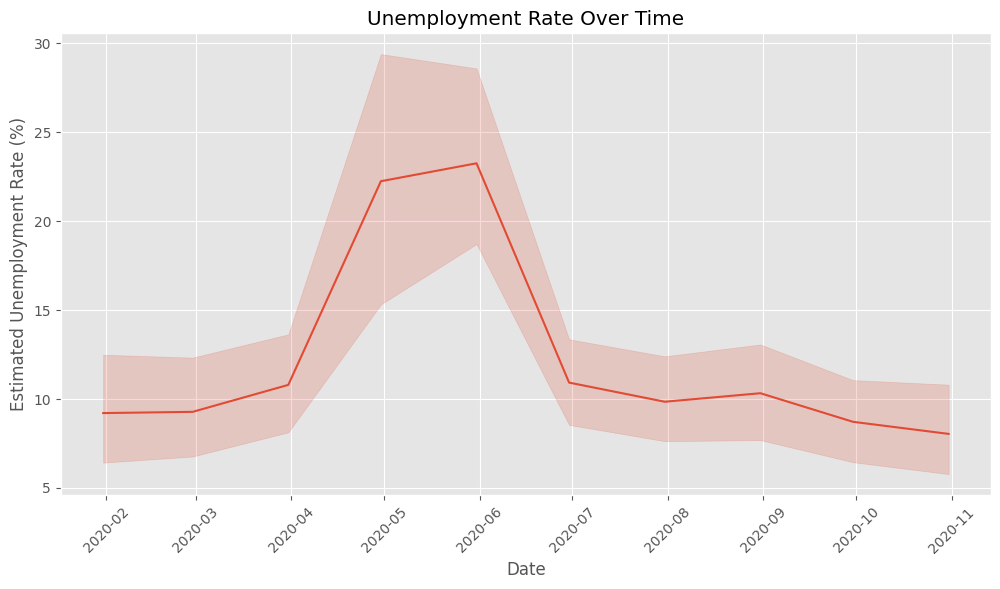

In [12]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate Over Time')
plt.xticks(rotation=45)

plt.show()

In [13]:
peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]

print(peak[['Date', 'Region', 'Estimated Unemployment Rate (%)']])

Date                               2020-04-30 00:00:00
Region                                      Puducherry
Estimated Unemployment Rate (%)                  75.85
Name: 172, dtype: object


In [14]:
monthly_avg = df.groupby(df['Date'].dt.month)[
    'Estimated Unemployment Rate (%)'
].mean()

print(monthly_avg)

Date
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64


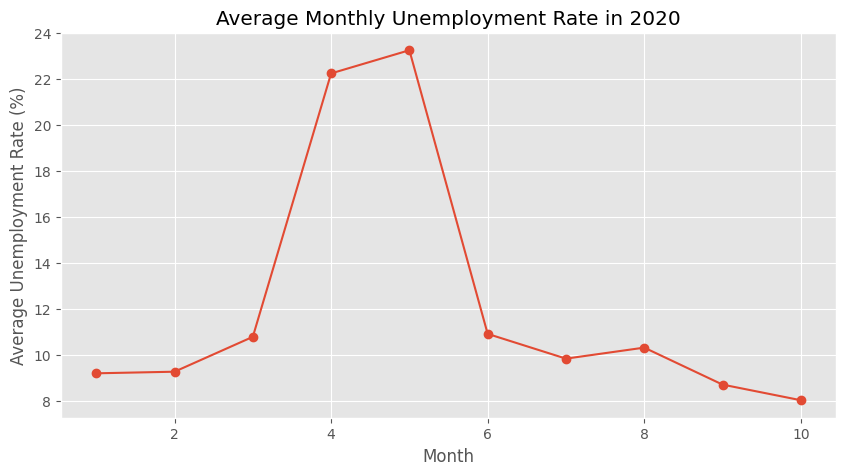

In [15]:
plt.figure(figsize=(10,5))

monthly_avg.plot(marker='o')

plt.title('Average Monthly Unemployment Rate in 2020')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.grid(True)

plt.show()

In [16]:
state_avg = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

state_avg.head(10)

,Estimated Unemployment Rate (%)
Region,
Haryana,27.477000
Tripura,25.055000
Jharkhand,19.539000
Bihar,19.471000
Delhi,18.414000
Puducherry,17.942000
Jammu & Kashmir,16.477778
Himachal Pradesh,16.065000
Rajasthan,15.868000


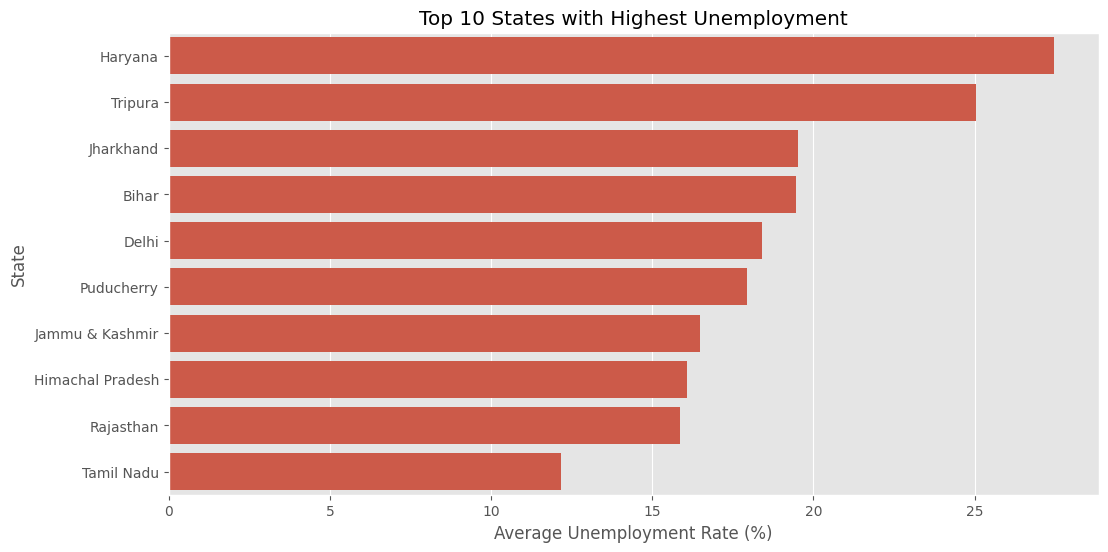

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_avg.head(10).values,
    y=state_avg.head(10).index
)

plt.title('Top 10 States with Highest Unemployment')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')

plt.show()

In [18]:
monthly_avg = df.groupby(df['Date'].dt.month)[
    'Estimated Unemployment Rate (%)'
].mean()

monthly_avg

,Estimated Unemployment Rate (%)
Date,
1,9.196538
2,9.266154
3,10.782593
4,22.236154
5,23.244444
6,10.911111
7,9.834444
8,10.313333
9,8.705926


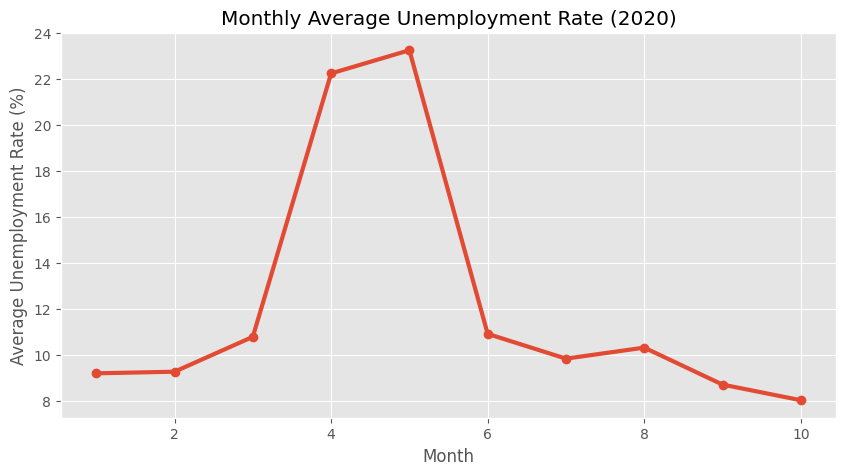

In [19]:
plt.figure(figsize=(10,5))

monthly_avg.plot(
    marker='o',
    linewidth=3
)

plt.title('Monthly Average Unemployment Rate (2020)')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.grid(True)

plt.show()

In [20]:
df['Region.1'].unique()

array(['South', 'Northeast', 'East', 'West', 'North'], dtype=object)

In [21]:
area_avg = df.groupby('Region.1')[
    'Estimated Unemployment Rate (%)'
].mean()

print(area_avg)

Region.1
East         13.916000
North        15.889620
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64


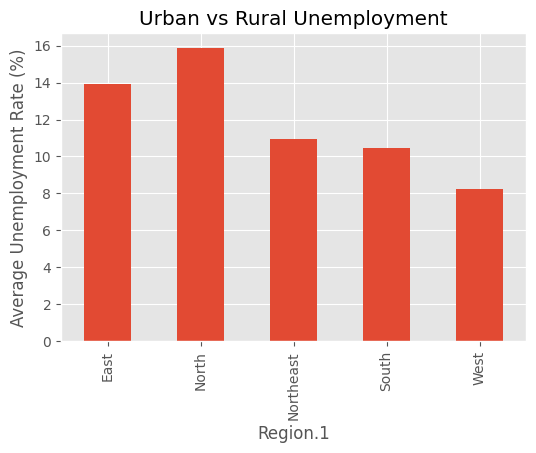

In [22]:
plt.figure(figsize=(6,4))

area_avg.plot(
    kind='bar'
)

plt.title('Urban vs Rural Unemployment')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

In [23]:
peak = df.loc[df['Estimated Unemployment Rate (%)'].idxmax()]

print(peak[['Region',
            'Date',
            'Estimated Unemployment Rate (%)']])

Region                                      Puducherry
Date                               2020-04-30 00:00:00
Estimated Unemployment Rate (%)                  75.85
Name: 172, dtype: object


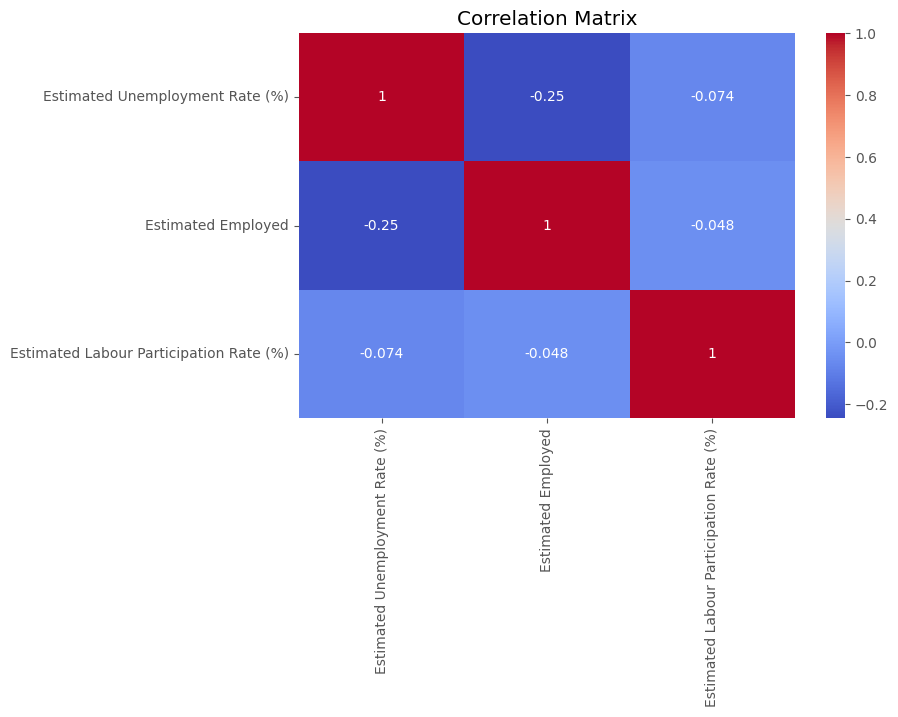

In [24]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

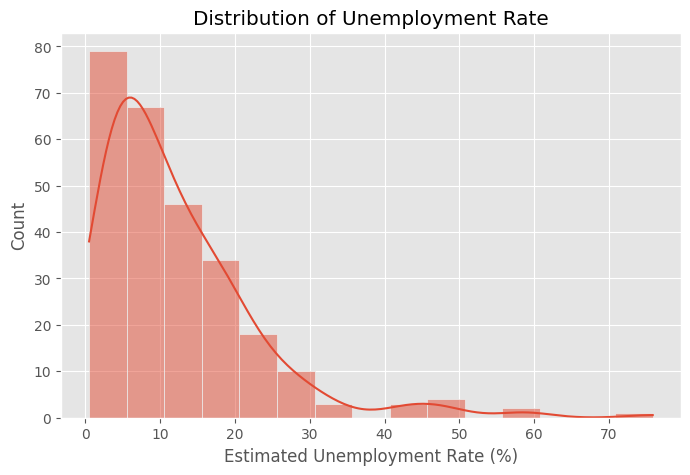

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=15,
    kde=True
)

plt.title('Distribution of Unemployment Rate')
plt.show()

In [26]:
plt.savefig('monthly_unemployment.png')
plt.savefig('statewise_unemployment.png')
plt.savefig('urban_rural_unemployment.png')
plt.savefig('correlation_matrix.png')

<Figure size 640x480 with 0 Axes>